# Data availability comparison -- plots

Loads the classification review CSVs and the full-corpus JSONL files, and plots the corpus-size / classified-so-far table and the Axis A / Axis B case-distribution charts used in the report.

Note: all classifications loaded here are agent-produced and not yet human-verified (see the report's Methodology section).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data"

quantum = pd.read_csv(f"{DATA_DIR}/quantum_axis_case_review.csv")
cs = pd.read_csv(f"{DATA_DIR}/cs_axis_case_review.csv")

# Case columns are strings like "1 - Not present"; unclassified rows read "not yet run".
def case_number(series):
    return series.str.extract(r"^(\d+)")[0].astype("Int64")

quantum_classified = quantum[quantum["Axis A Case"] != "not yet run"]
cs_classified = cs[cs["Axis A Case"] != "not yet run"]

## Corpus size and classification status

In [2]:
# Full category-based corpus sizes are fixed (Table tab:corpus-stats in the report);
# classified counts are read live from the CSVs above.
summary = pd.DataFrame({
    "Corpus size": {"Quantum": 109321, "CS": 345107},
    "Classified so far": {"Quantum": len(quantum_classified), "CS": len(cs_classified)},
})
summary["% classified"] = (summary["Classified so far"] / summary["Corpus size"] * 100).round(2)
summary

,Corpus size,Classified so far,% classified
Quantum,109321,3472,3.18
CS,345107,1872,0.54


## Axis A (External Data) case distribution

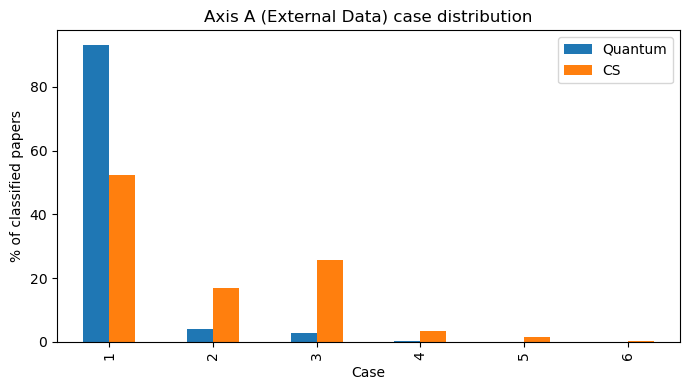

In [3]:
def case_distribution_pct(df, column):
    counts = case_number(df[column]).value_counts().reindex(range(1, 7), fill_value=0)
    return counts / counts.sum() * 100

axis_a = pd.DataFrame({
    "Quantum": case_distribution_pct(quantum_classified, "Axis A Case"),
    "CS": case_distribution_pct(cs_classified, "Axis A Case"),
})

axis_a.plot(kind="bar", figsize=(7, 4), title="Axis A (External Data) case distribution")
plt.xlabel("Case")
plt.ylabel("% of classified papers")
plt.tight_layout()
plt.savefig("axis_a_distribution.png")
plt.show()

## Axis B (Self-Generated Data) case distribution

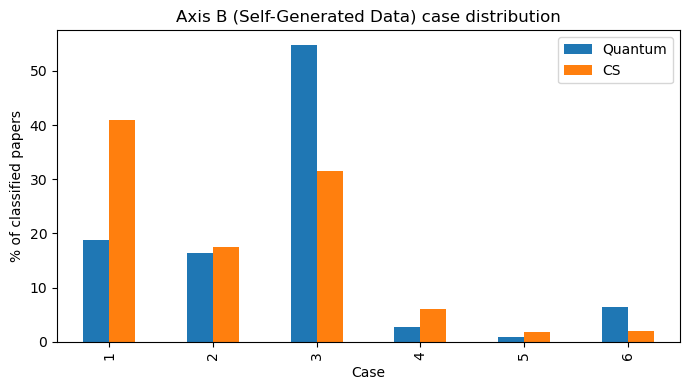

In [4]:
axis_b = pd.DataFrame({
    "Quantum": case_distribution_pct(quantum_classified, "Axis B Case"),
    "CS": case_distribution_pct(cs_classified, "Axis B Case"),
})

axis_b.plot(kind="bar", figsize=(7, 4), title="Axis B (Self-Generated Data) case distribution")
plt.xlabel("Case")
plt.ylabel("% of classified papers")
plt.tight_layout()
plt.savefig("axis_b_distribution.png")
plt.show()

## Data present vs. not present vs. unclassified, per axis

Out of each domain's *full* corpus (not just what's been classified so far): how many papers show data present (Case 2-6) on that axis, how many show it not present (Case 1), and how many haven't been classified yet.

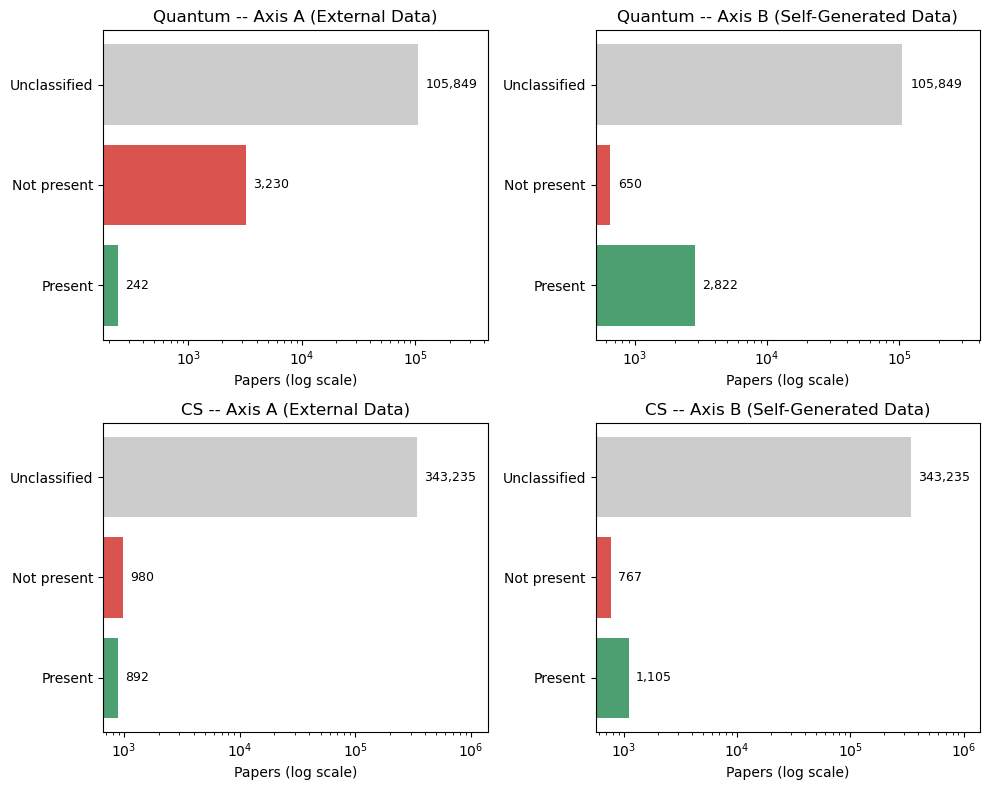

In [5]:
CORPUS_SIZE = {"Quantum": 109321, "CS": 345107}

def presence_breakdown(df, column, domain):
    n_present = int((case_number(df[column]) != 1).sum())
    n_not_present = int((case_number(df[column]) == 1).sum())
    n_unclassified = CORPUS_SIZE[domain] - len(df)
    return [n_present, n_not_present, n_unclassified]

labels = ["Present", "Not present", "Unclassified"]
colors = ["#4C9F70", "#D9534F", "#CCCCCC"]

# Unclassified dwarfs the other two categories (>95% of the corpus), which made the
# pie slices for Present/Not present too small to read. A log-scale horizontal bar,
# with the exact count written next to every bar, stays readable at any scale.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plots = [
    ("Quantum", "Axis A Case", quantum_classified, axes[0, 0], "Quantum -- Axis A (External Data)"),
    ("Quantum", "Axis B Case", quantum_classified, axes[0, 1], "Quantum -- Axis B (Self-Generated Data)"),
    ("CS", "Axis A Case", cs_classified, axes[1, 0], "CS -- Axis A (External Data)"),
    ("CS", "Axis B Case", cs_classified, axes[1, 1], "CS -- Axis B (Self-Generated Data)"),
]

for domain, column, df, ax, title in plots:
    sizes = presence_breakdown(df, column, domain)
    bars = ax.barh(labels, sizes, color=colors)
    ax.set_xscale("log")
    ax.set_xlabel("Papers (log scale)")
    ax.set_title(title)
    for bar, value in zip(bars, sizes):
        ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
                 f"{value:,}", va="center", fontsize=9)
    ax.set_xlim(right=ax.get_xlim()[1] * 3)  # leave room for the labels

plt.tight_layout()
plt.savefig("presence_vs_unclassified_bars.png")
plt.show()

## Data present, Axis A vs. Axis B, CS vs. Quantum (classified papers only)

One chart, linear scale, restricted to papers already classified (no "unclassified" bucket here): CS on the left, Quantum on the right, each with its Axis A and Axis B present-counts side by side.

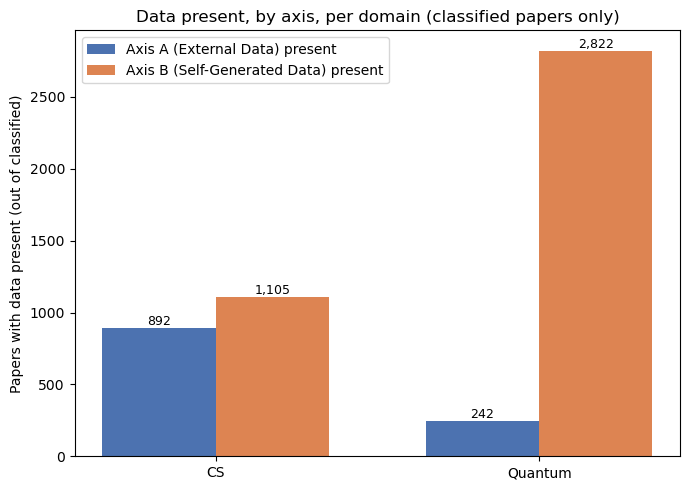

In [6]:
present_counts = {
    "CS": {
        "Axis A": int((case_number(cs_classified["Axis A Case"]) != 1).sum()),
        "Axis B": int((case_number(cs_classified["Axis B Case"]) != 1).sum()),
    },
    "Quantum": {
        "Axis A": int((case_number(quantum_classified["Axis A Case"]) != 1).sum()),
        "Axis B": int((case_number(quantum_classified["Axis B Case"]) != 1).sum()),
    },
}

domains = ["CS", "Quantum"]  # CS on the left, Quantum on the right
axis_a_vals = [present_counts[d]["Axis A"] for d in domains]
axis_b_vals = [present_counts[d]["Axis B"] for d in domains]

x = range(len(domains))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars_a = ax.bar([i - width / 2 for i in x], axis_a_vals, width,
                label="Axis A (External Data) present", color="#4C72B0")
bars_b = ax.bar([i + width / 2 for i in x], axis_b_vals, width,
                label="Axis B (Self-Generated Data) present", color="#DD8452")

ax.set_xticks(list(x))
ax.set_xticklabels(domains)
ax.set_ylabel("Papers with data present (out of classified)")
ax.set_title("Data present, by axis, per domain (classified papers only)")
ax.legend()

for bars in (bars_a, bars_b):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{bar.get_height():,}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("present_by_axis_domain.png")
plt.show()

## Has data vs. no data vs. left to classify, per domain

A paper counts as "has data" if either axis shows data present (Case 2-6); "no data" only if *both* axes are Case 1 (the framework's definition of a fully theoretical paper -- see AGENT_CLASSIFICATION_PROMPT.md). Linear scale, exact counts labeled on every bar.

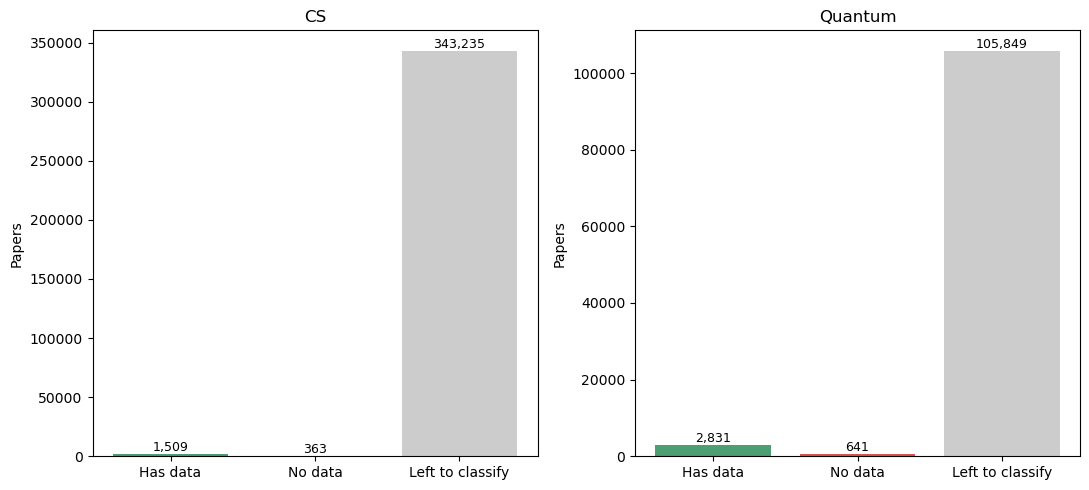

In [7]:
def has_no_left_breakdown(df, domain):
    a = case_number(df["Axis A Case"])
    b = case_number(df["Axis B Case"])
    has_data = int(((a != 1) | (b != 1)).sum())
    no_data = int(((a == 1) & (b == 1)).sum())
    left_to_classify = CORPUS_SIZE[domain] - len(df)
    return has_data, no_data, left_to_classify

cats = ["Has data", "No data", "Left to classify"]
colors2 = ["#4C9F70", "#D9534F", "#CCCCCC"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)

for ax, domain, df in zip(axes, ["CS", "Quantum"], [cs_classified, quantum_classified]):
    values = has_no_left_breakdown(df, domain)
    bars = ax.bar(cats, values, color=colors2)
    ax.set_title(domain)
    ax.set_ylabel("Papers")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("has_no_left_to_classify.png")
plt.show()

### Same breakdown, as a percentage of each domain's full corpus

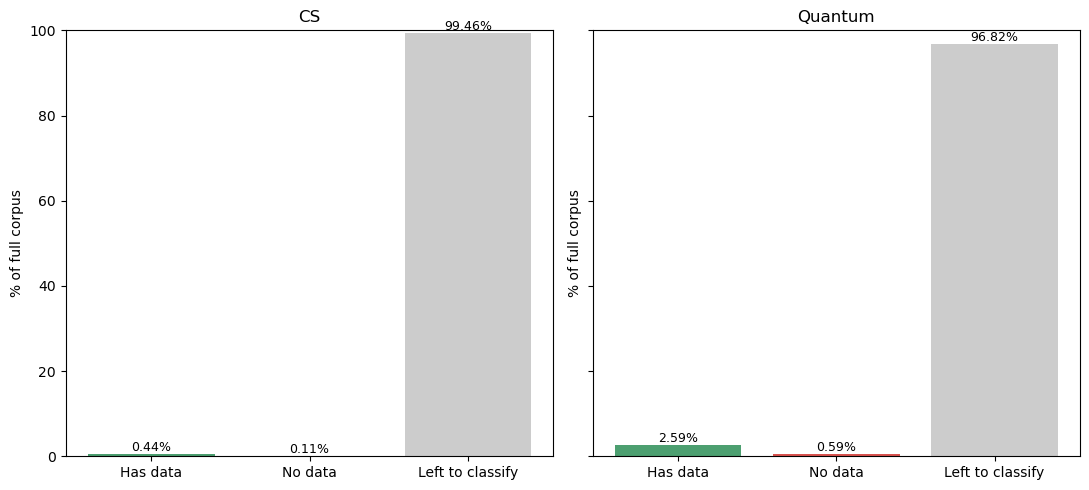

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, domain, df in zip(axes, ["CS", "Quantum"], [cs_classified, quantum_classified]):
    values = has_no_left_breakdown(df, domain)
    pcts = [v / CORPUS_SIZE[domain] * 100 for v in values]
    bars = ax.bar(cats, pcts, color=colors2)
    ax.set_title(domain)
    ax.set_ylabel("% of full corpus")
    ax.set_ylim(0, 100)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("has_no_left_to_classify_pct.png")
plt.show()

## Theoretical vs. used-but-not-shared vs. used-and-shared, per domain

Splits the "has data" bucket from above by whether it was actually shared:
- **Theoretical (no data)**: both axes are Case 1 -- no data of either kind was used.
- **Used, not shared**: at least one axis is Case 3, 4, 5, or 6 -- data was used (external, self-generated, or both) but that axis was not directly, verifiably accessible (named-but-uncited, underspecified, claimed-but-broken, or request-only). This is the paper actually using data and not making it available.
- **Used, shared**: every axis with data present is Case 2 (directly accessible) -- no unshared axis.
- **Left to classify**: not yet processed.

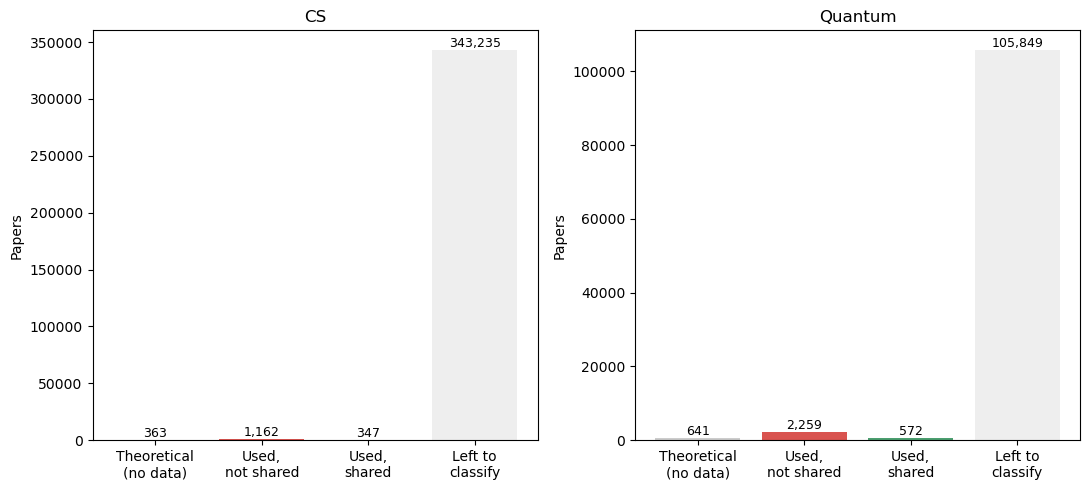

In [9]:
def shared_breakdown(df, domain):
    a = case_number(df["Axis A Case"])
    b = case_number(df["Axis B Case"])
    theoretical = int(((a == 1) & (b == 1)).sum())
    not_shared = int((a.isin([3, 4, 5, 6]) | b.isin([3, 4, 5, 6])).sum())
    used_shared = len(df) - theoretical - not_shared
    left_to_classify = CORPUS_SIZE[domain] - len(df)
    return theoretical, not_shared, used_shared, left_to_classify

cats3 = ["Theoretical\n(no data)", "Used,\nnot shared", "Used,\nshared", "Left to\nclassify"]
colors3 = ["#CCCCCC", "#D9534F", "#4C9F70", "#EEEEEE"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, domain, df in zip(axes, ["CS", "Quantum"], [cs_classified, quantum_classified]):
    values = shared_breakdown(df, domain)
    bars = ax.bar(cats3, values, color=colors3)
    ax.set_title(domain)
    ax.set_ylabel("Papers")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("theoretical_shared_unshared.png")
plt.show()

### Same idea, just the two data-using buckets: shared vs. not shared

Drops "Theoretical" and "Left to classify" from the picture above -- this is restricted
to papers that use data at all (either axis, or both), split only into whether they
made it available or not. "Not shared" here means the paper uses/names/describes/claims
the data (Case 3, 4, 5, or 6) but doesn't hand it over with a working link -- same
shared/not-shared logic as the chart above, just isolated to a plain two-bar comparison.

**"Uses data" explicitly means "not theoretical"**: every classified paper is either
theoretical (Case 1 on both axes -- no data of any kind) or uses data (Case 2-6 on at
least one axis). The n in each bar chart's title below is that "uses data" count --
classified total minus theoretical -- so a theoretical paper never appears in either
the "Shared" or "Not shared" bar; it has nothing to share in the first place.

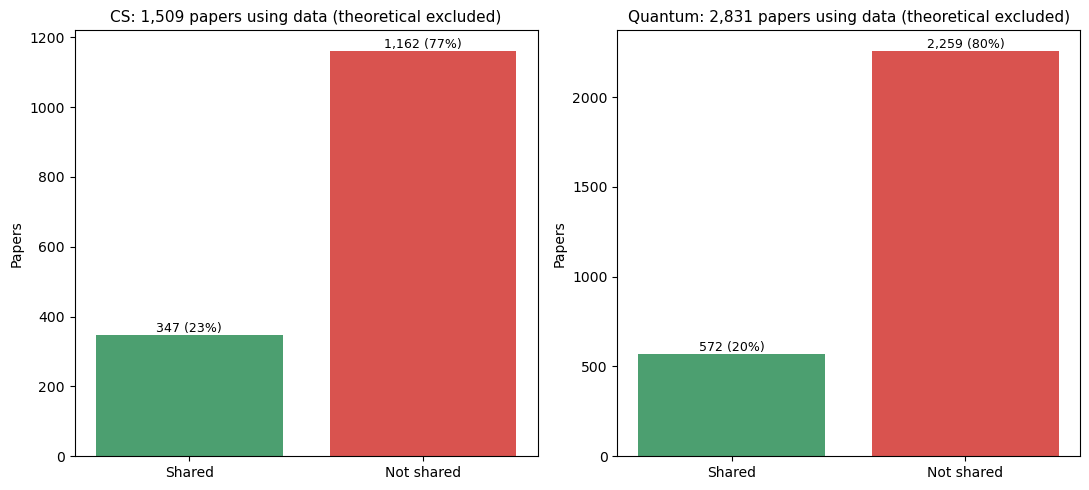

In [10]:
cats_shared = ["Shared", "Not shared"]
colors_shared = ["#4C9F70", "#D9534F"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, domain, df in zip(axes, ["CS", "Quantum"], [cs_classified, quantum_classified]):
    theoretical, not_shared, used_shared, _ = shared_breakdown(df, domain)
    values = [used_shared, not_shared]
    n_uses_data = used_shared + not_shared
    bars = ax.bar(cats_shared, values, color=colors_shared)
    ax.set_title(f"{domain}: {n_uses_data:,} papers using data (theoretical excluded)", fontsize=11)
    ax.set_ylabel("Papers")
    for bar, value in zip(bars, values):
        pct = value / n_uses_data * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,} ({pct:.0f}%)",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("shared_vs_not_shared.png")
plt.show()

## Input shared vs. output shared, among papers using data on both axes

Restricted to papers where *both* axes have data present (Axis A != 1 and Axis B != 1) -- otherwise "input vs. output" doesn't apply. Among those papers only:
- **Both shared**: Axis A = 2 and Axis B = 2.
- **Input shared, output not**: Axis A = 2, Axis B in {3,4,5,6} -- external data made available, self-generated (experiment output) data withheld.
- **Output shared, input not**: Axis A in {3,4,5,6}, Axis B = 2 -- the reverse.
- **Neither shared**: Axis A in {3,4,5,6} and Axis B in {3,4,5,6}.

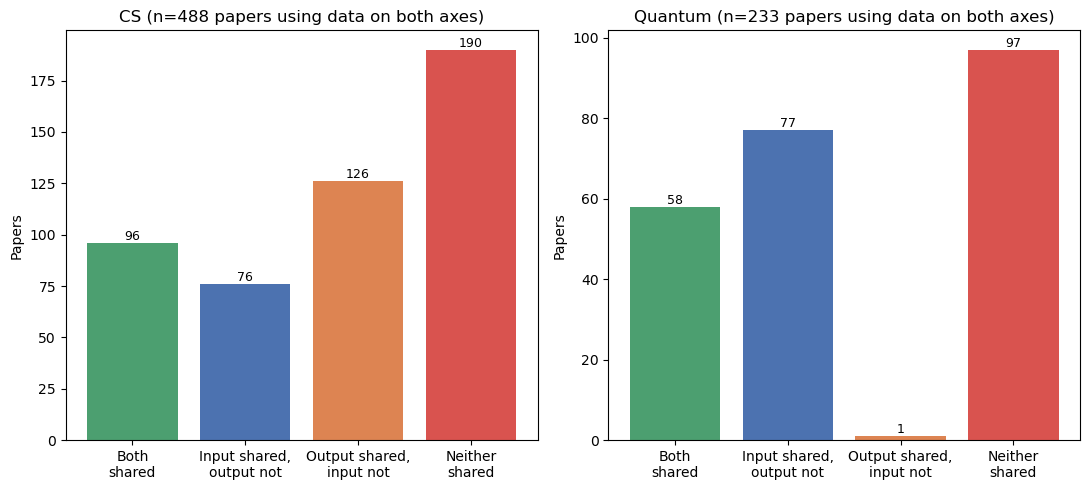

In [11]:
def input_output_breakdown(df):
    a = case_number(df["Axis A Case"])
    b = case_number(df["Axis B Case"])
    both_present = (a != 1) & (b != 1)
    a, b = a[both_present], b[both_present]
    both_shared = int(((a == 2) & (b == 2)).sum())
    input_only = int(((a == 2) & (b.isin([3, 4, 5, 6]))).sum())
    output_only = int((a.isin([3, 4, 5, 6]) & (b == 2)).sum())
    neither = int((a.isin([3, 4, 5, 6]) & b.isin([3, 4, 5, 6])).sum())
    return both_present.sum(), (both_shared, input_only, output_only, neither)

cats4 = ["Both\nshared", "Input shared,\noutput not", "Output shared,\ninput not", "Neither\nshared"]
colors4 = ["#4C9F70", "#4C72B0", "#DD8452", "#D9534F"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, domain, df in zip(axes, ["CS", "Quantum"], [cs_classified, quantum_classified]):
    n_both_present, values = input_output_breakdown(df)
    bars = ax.bar(cats4, values, color=colors4)
    ax.set_title(f"{domain} (n={n_both_present} papers using data on both axes)")
    ax.set_ylabel("Papers")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("input_vs_output_shared.png")
plt.show()

## Full funnel: uses data? -> which data? -> shared?

One flow diagram per domain, all three questions in one picture, starting from every classified paper:
1. **Uses data or not** -- theoretical (Case 1 on both axes) vs. uses data on at least one axis.
2. **Which data** -- of the papers using data: external only, self-generated only, or both.
3. **Shared or not** -- for external-only and self-generated-only papers: shared (Case 2) vs. not shared (Case 3-6) on that one axis. For "both": the four-way input/output split from the previous chart.

Uses `plotly` instead of `matplotlib` here -- a Sankey diagram is the natural way to draw a branching flow like this, and matplotlib doesn't have a good equivalent for more than one branch point.

In [12]:
import plotly.graph_objects as go

def funnel_numbers(df):
    a = case_number(df["Axis A Case"])
    b = case_number(df["Axis B Case"])

    theoretical = ((a == 1) & (b == 1))
    ext_only = ((a != 1) & (b == 1))
    selfgen_only = ((a == 1) & (b != 1))
    both = ((a != 1) & (b != 1))

    ea = a[ext_only]
    ext_shared, ext_not_shared = int((ea == 2).sum()), int(ea.isin([3, 4, 5, 6]).sum())

    sb = b[selfgen_only]
    self_shared, self_not_shared = int((sb == 2).sum()), int(sb.isin([3, 4, 5, 6]).sum())

    ba, bb = a[both], b[both]
    both_shared = int(((ba == 2) & (bb == 2)).sum())
    input_only = int(((ba == 2) & (bb.isin([3, 4, 5, 6]))).sum())
    output_only = int((ba.isin([3, 4, 5, 6]) & (bb == 2)).sum())
    neither = int((ba.isin([3, 4, 5, 6]) & bb.isin([3, 4, 5, 6])).sum())

    return {
        "classified": len(df), "theoretical": int(theoretical.sum()),
        "ext_only": int(ext_only.sum()), "selfgen_only": int(selfgen_only.sum()), "both": int(both.sum()),
        "ext_shared": ext_shared, "ext_not_shared": ext_not_shared,
        "self_shared": self_shared, "self_not_shared": self_not_shared,
        "both_shared": both_shared, "input_only": input_only, "output_only": output_only, "neither": neither,
    }

# Node colors are meaningful, not just Plotly's default palette: grey for routing/
# theoretical nodes, blue/orange/purple for which data type a paper uses, green for
# actually shared, amber for partially shared, red for not shared at all.
COLOR_ROUTING = "#7F7F7F"
COLOR_THEORETICAL = "#CCCCCC"
COLOR_EXTERNAL = "#4C72B0"
COLOR_SELFGEN = "#DD8452"
COLOR_BOTH = "#8172B2"
COLOR_SHARED = "#4C9F70"
COLOR_PARTIAL = "#F0AD4E"
COLOR_NOT_SHARED = "#D9534F"

LEGEND_ITEMS = [
    ("External data used (Axis A)", COLOR_EXTERNAL),
    ("Self-generated data used (Axis B)", COLOR_SELFGEN),
    ("Both axes used", COLOR_BOTH),
    ("Shared (Case 2: directly accessible)", COLOR_SHARED),
    ("Partially shared (input or output only)", COLOR_PARTIAL),
    ("Not shared (Case 3-6)", COLOR_NOT_SHARED),
    ("Theoretical / routing (no data, or not yet split)", COLOR_THEORETICAL),
]

DEFINITIONS_TEXT = (
    "<b>External</b> = data used from outside the paper (Axis A).  "
    "<b>Self-generated</b> = data the paper's own experiment produced (Axis B).<br>"
    "<b>Both</b> = the paper uses data on both axes.  "
    "<b>Shared</b> = a working, directly accessible link (Case 2).  "
    "<b>Not shared</b> = data is used but not directly accessible (Case 3, 4, 5, or 6)."
)

def make_sankey(n, title):
    labels = [
        "Classified", "Uses data", "Theoretical (no data)",
        "External only", "Self-generated only", "Both",
        "External-only: shared", "External-only: not shared",
        "Self-gen-only: shared", "Self-gen-only: not shared",
        "Both: shared", "Both: input only", "Both: output only", "Both: neither shared",
    ]
    node_colors = [
        COLOR_ROUTING, COLOR_ROUTING, COLOR_THEORETICAL,
        COLOR_EXTERNAL, COLOR_SELFGEN, COLOR_BOTH,
        COLOR_SHARED, COLOR_NOT_SHARED,
        COLOR_SHARED, COLOR_NOT_SHARED,
        COLOR_SHARED, COLOR_PARTIAL, COLOR_PARTIAL, COLOR_NOT_SHARED,
    ]
    # Explicit column (x) AND row (y) per node, arrangement="fixed" so Plotly honors
    # them exactly. Without this, Plotly places a node by its LONGEST path from any
    # source, so "Theoretical" (only 1 hop from "Classified", no further split) got
    # shoved into the same rightmost column as leaf nodes 3 hops away, and its ribbon
    # had to curve all the way across the diagram instead of splitting off cleanly
    # right next to "Uses data". ("snap" arrangement was tried first and still ignored
    # the column hint for this node, hence "fixed".)
    node_x = [
        0.001,
        0.26, 0.26,
        0.55, 0.55, 0.55,
        0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99,
    ]
    node_y = [
        0.45,               # 0 Classified
        0.25, 0.85,          # 1 Uses data, 2 Theoretical
        0.55, 0.15, 0.80,    # 3 External only, 4 Self-generated only, 5 Both
        0.50, 0.58, 0.03, 0.20, 0.65, 0.72, 0.80, 0.92,  # 6-13 leaf nodes
    ]
    src = [0, 0, 1, 1, 1, 3, 3, 4, 4, 5, 5, 5, 5]
    tgt = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    values = [
        n["classified"],  # node 0's own size, not a link value -- see note below
        n["ext_only"] + n["selfgen_only"] + n["both"], n["theoretical"],
        n["ext_only"], n["selfgen_only"], n["both"],
        n["ext_shared"], n["ext_not_shared"],
        n["self_shared"], n["self_not_shared"],
        n["both_shared"], n["input_only"], n["output_only"], n["neither"],
    ]
    link_values = values[1:]  # one value per link (src/tgt pair); values[0] is only used for the node label below

    # Generous padding/thickness/margins and a taller, wider canvas -- the default
    # sizing packed the many nodes too close together to read.
    fig = go.Figure(go.Sankey(
        arrangement="fixed",  # take node_x/node_y literally, don't auto-relayout
        node=dict(
            label=[f"{label} ({value:,})" for label, value in zip(labels, values)],
            color=node_colors,
            x=node_x, y=node_y,
            pad=40, thickness=24,
            line=dict(color="black", width=0.5),
        ),
        link=dict(source=src, target=tgt, value=link_values),
    ))

    # Sankey traces have no native legend, so fake one with invisible scatter points
    # that only exist to put a colored, labeled entry in the legend. This pulls in a
    # default cartesian x/y axis (ticks, gridlines) that means nothing here -- a
    # Sankey has no quantitative axes, so hide both explicitly.
    for name, color in LEGEND_ITEMS:
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode="markers",
            marker=dict(size=10, color=color),
            name=name, showlegend=True,
        ))
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)

    # The plot area's height is (total height - margin.t - margin.b); legend/annotation
    # y values are fractions of THAT area, not the full canvas, so they must stay well
    # inside margin.b or kaleido's static export clips them off the bottom of the image.
    corpus_total = CORPUS_SIZE[title]
    fig.update_layout(
        title_text=(
            f"{title} Data Availability Funnel "
            f"(n={n['classified']:,} classified, out of {corpus_total:,} total papers)"
        ),
        font_size=13,
        paper_bgcolor="white", plot_bgcolor="white",
        width=1150, height=900,
        margin=dict(l=30, r=30, t=60, b=200),
        legend=dict(orientation="h", yanchor="top", y=-0.08, xanchor="center", x=0.5, font_size=11),
        annotations=[dict(
            text=DEFINITIONS_TEXT, showarrow=False,
            xref="paper", yref="paper", x=0.5, y=-0.27,
            font=dict(size=11), align="center",
        )],
    )
    return fig

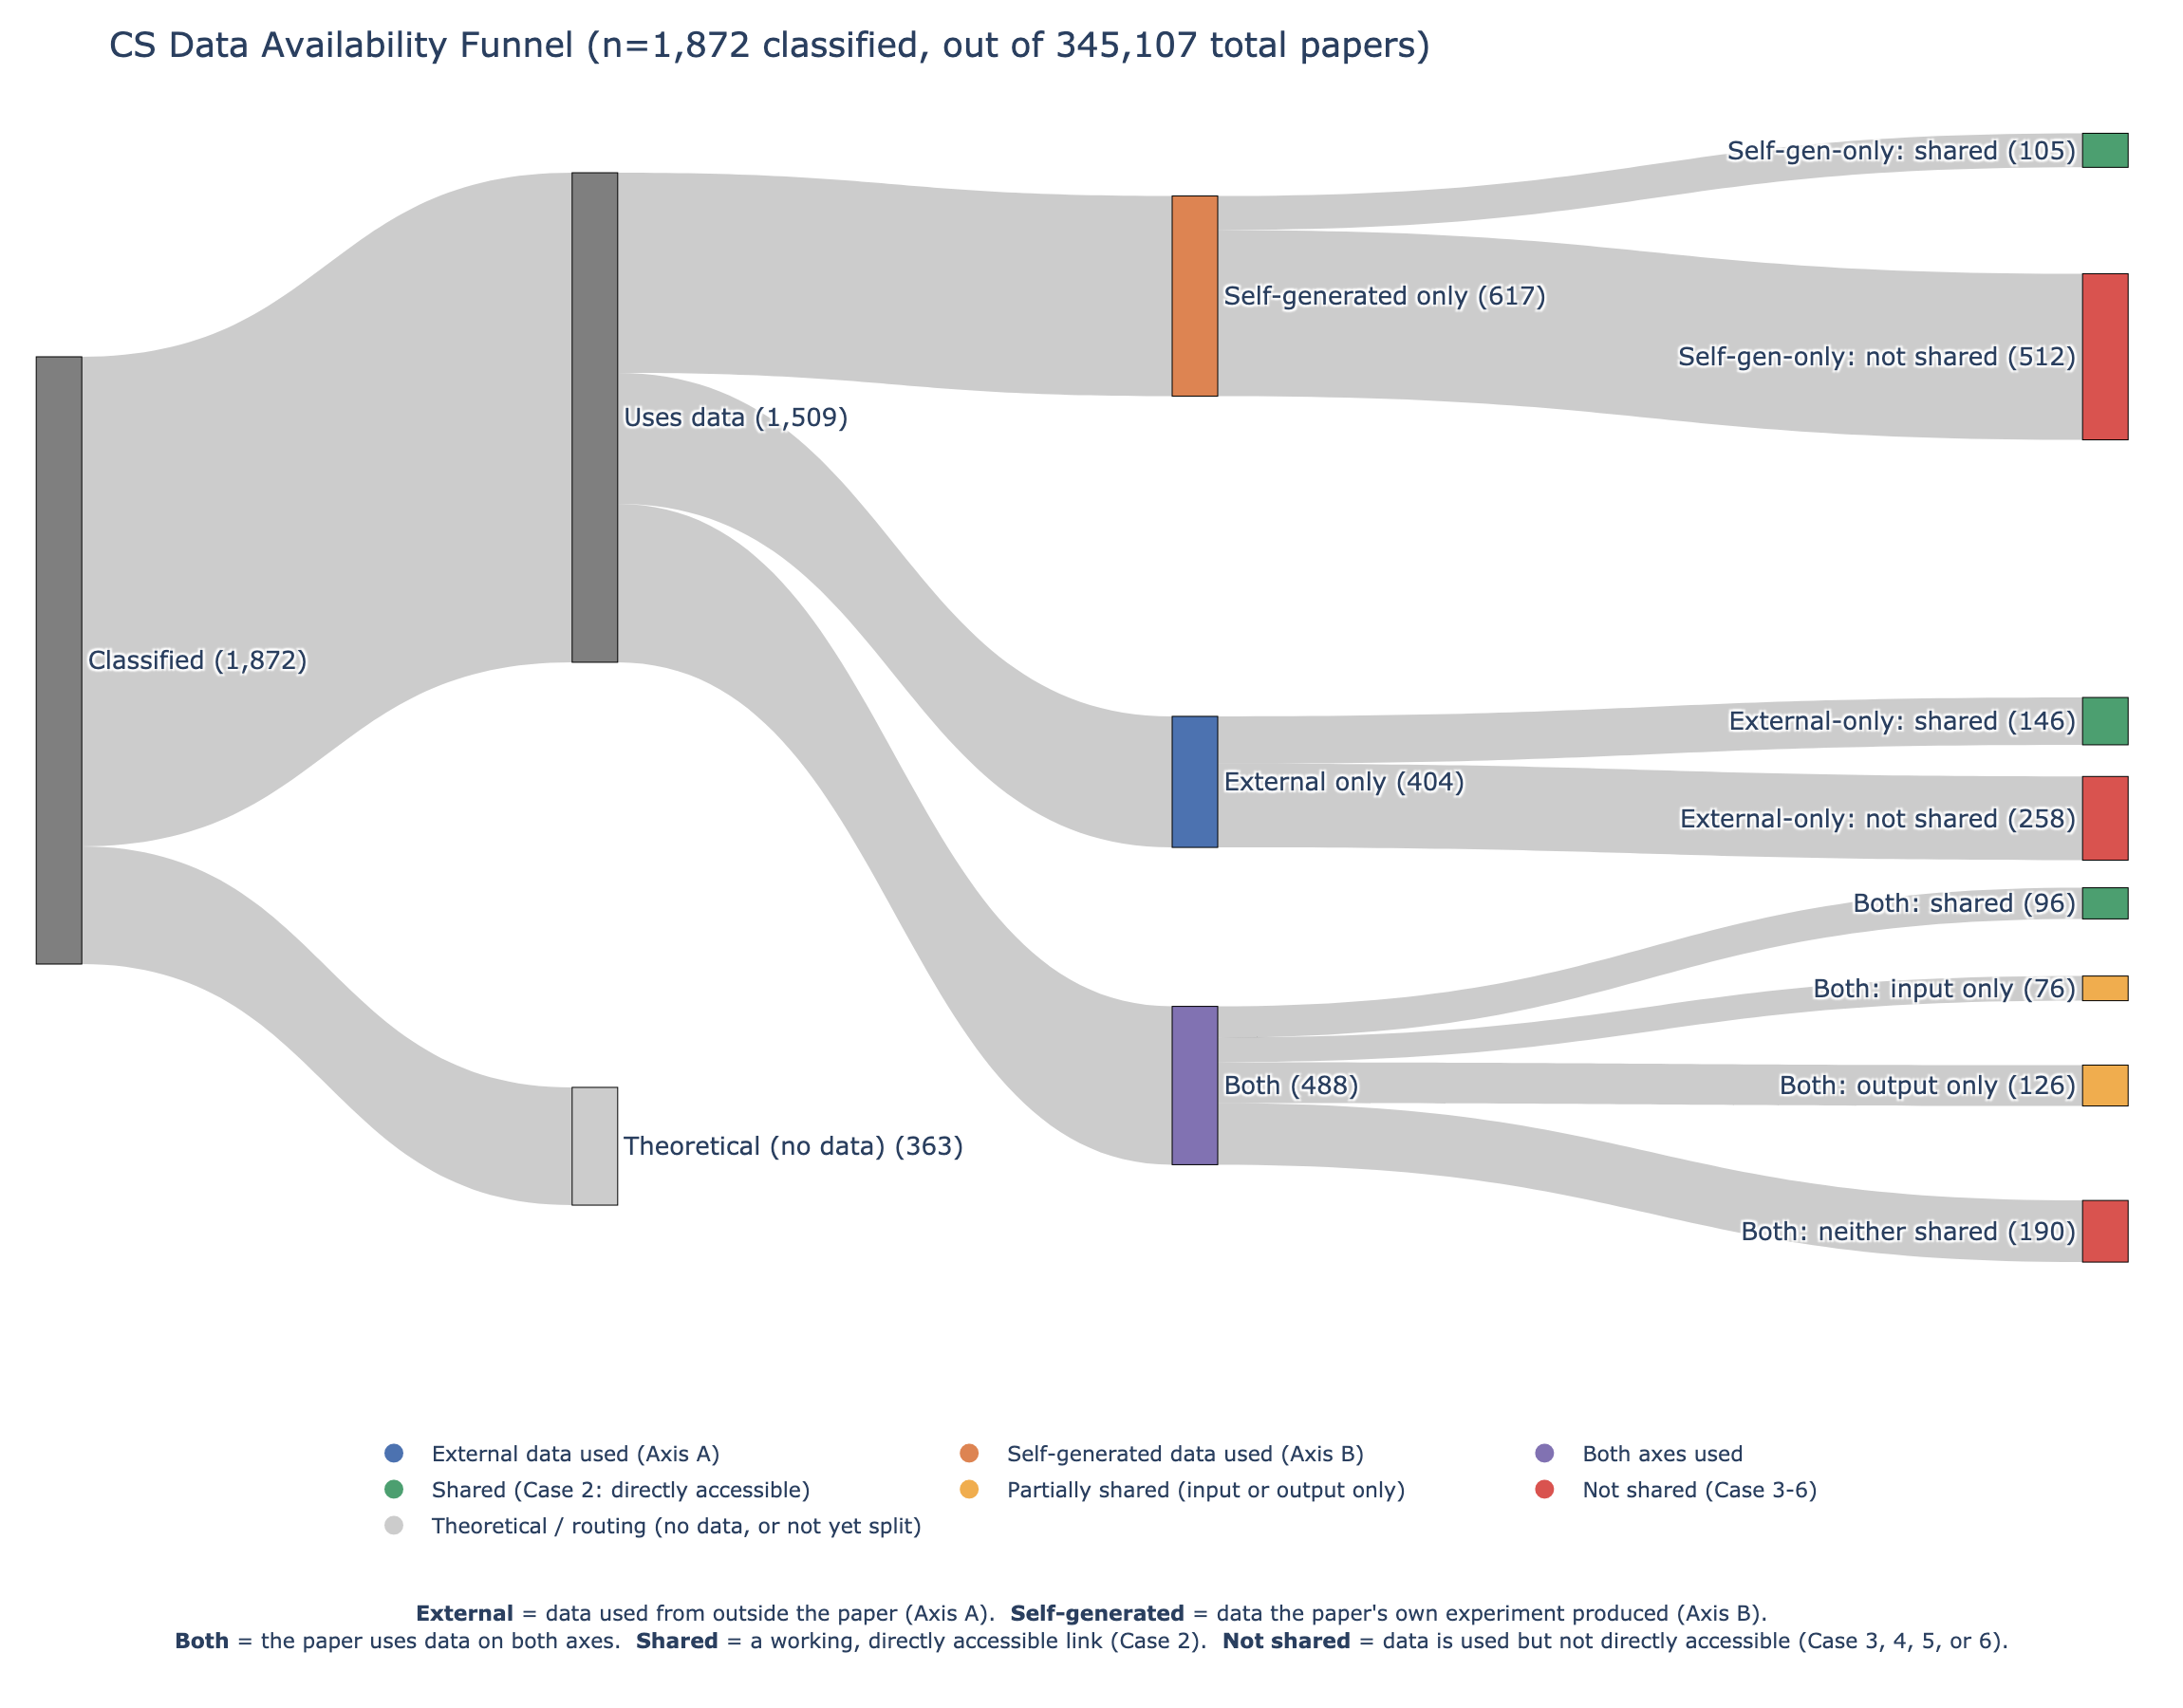

In [13]:
from IPython.display import Image, display

n_cs = funnel_numbers(cs_classified)
fig_cs = make_sankey(n_cs, "CS")
fig_cs.write_image("funnel_cs.png", scale=2)
display(Image("funnel_cs.png"))

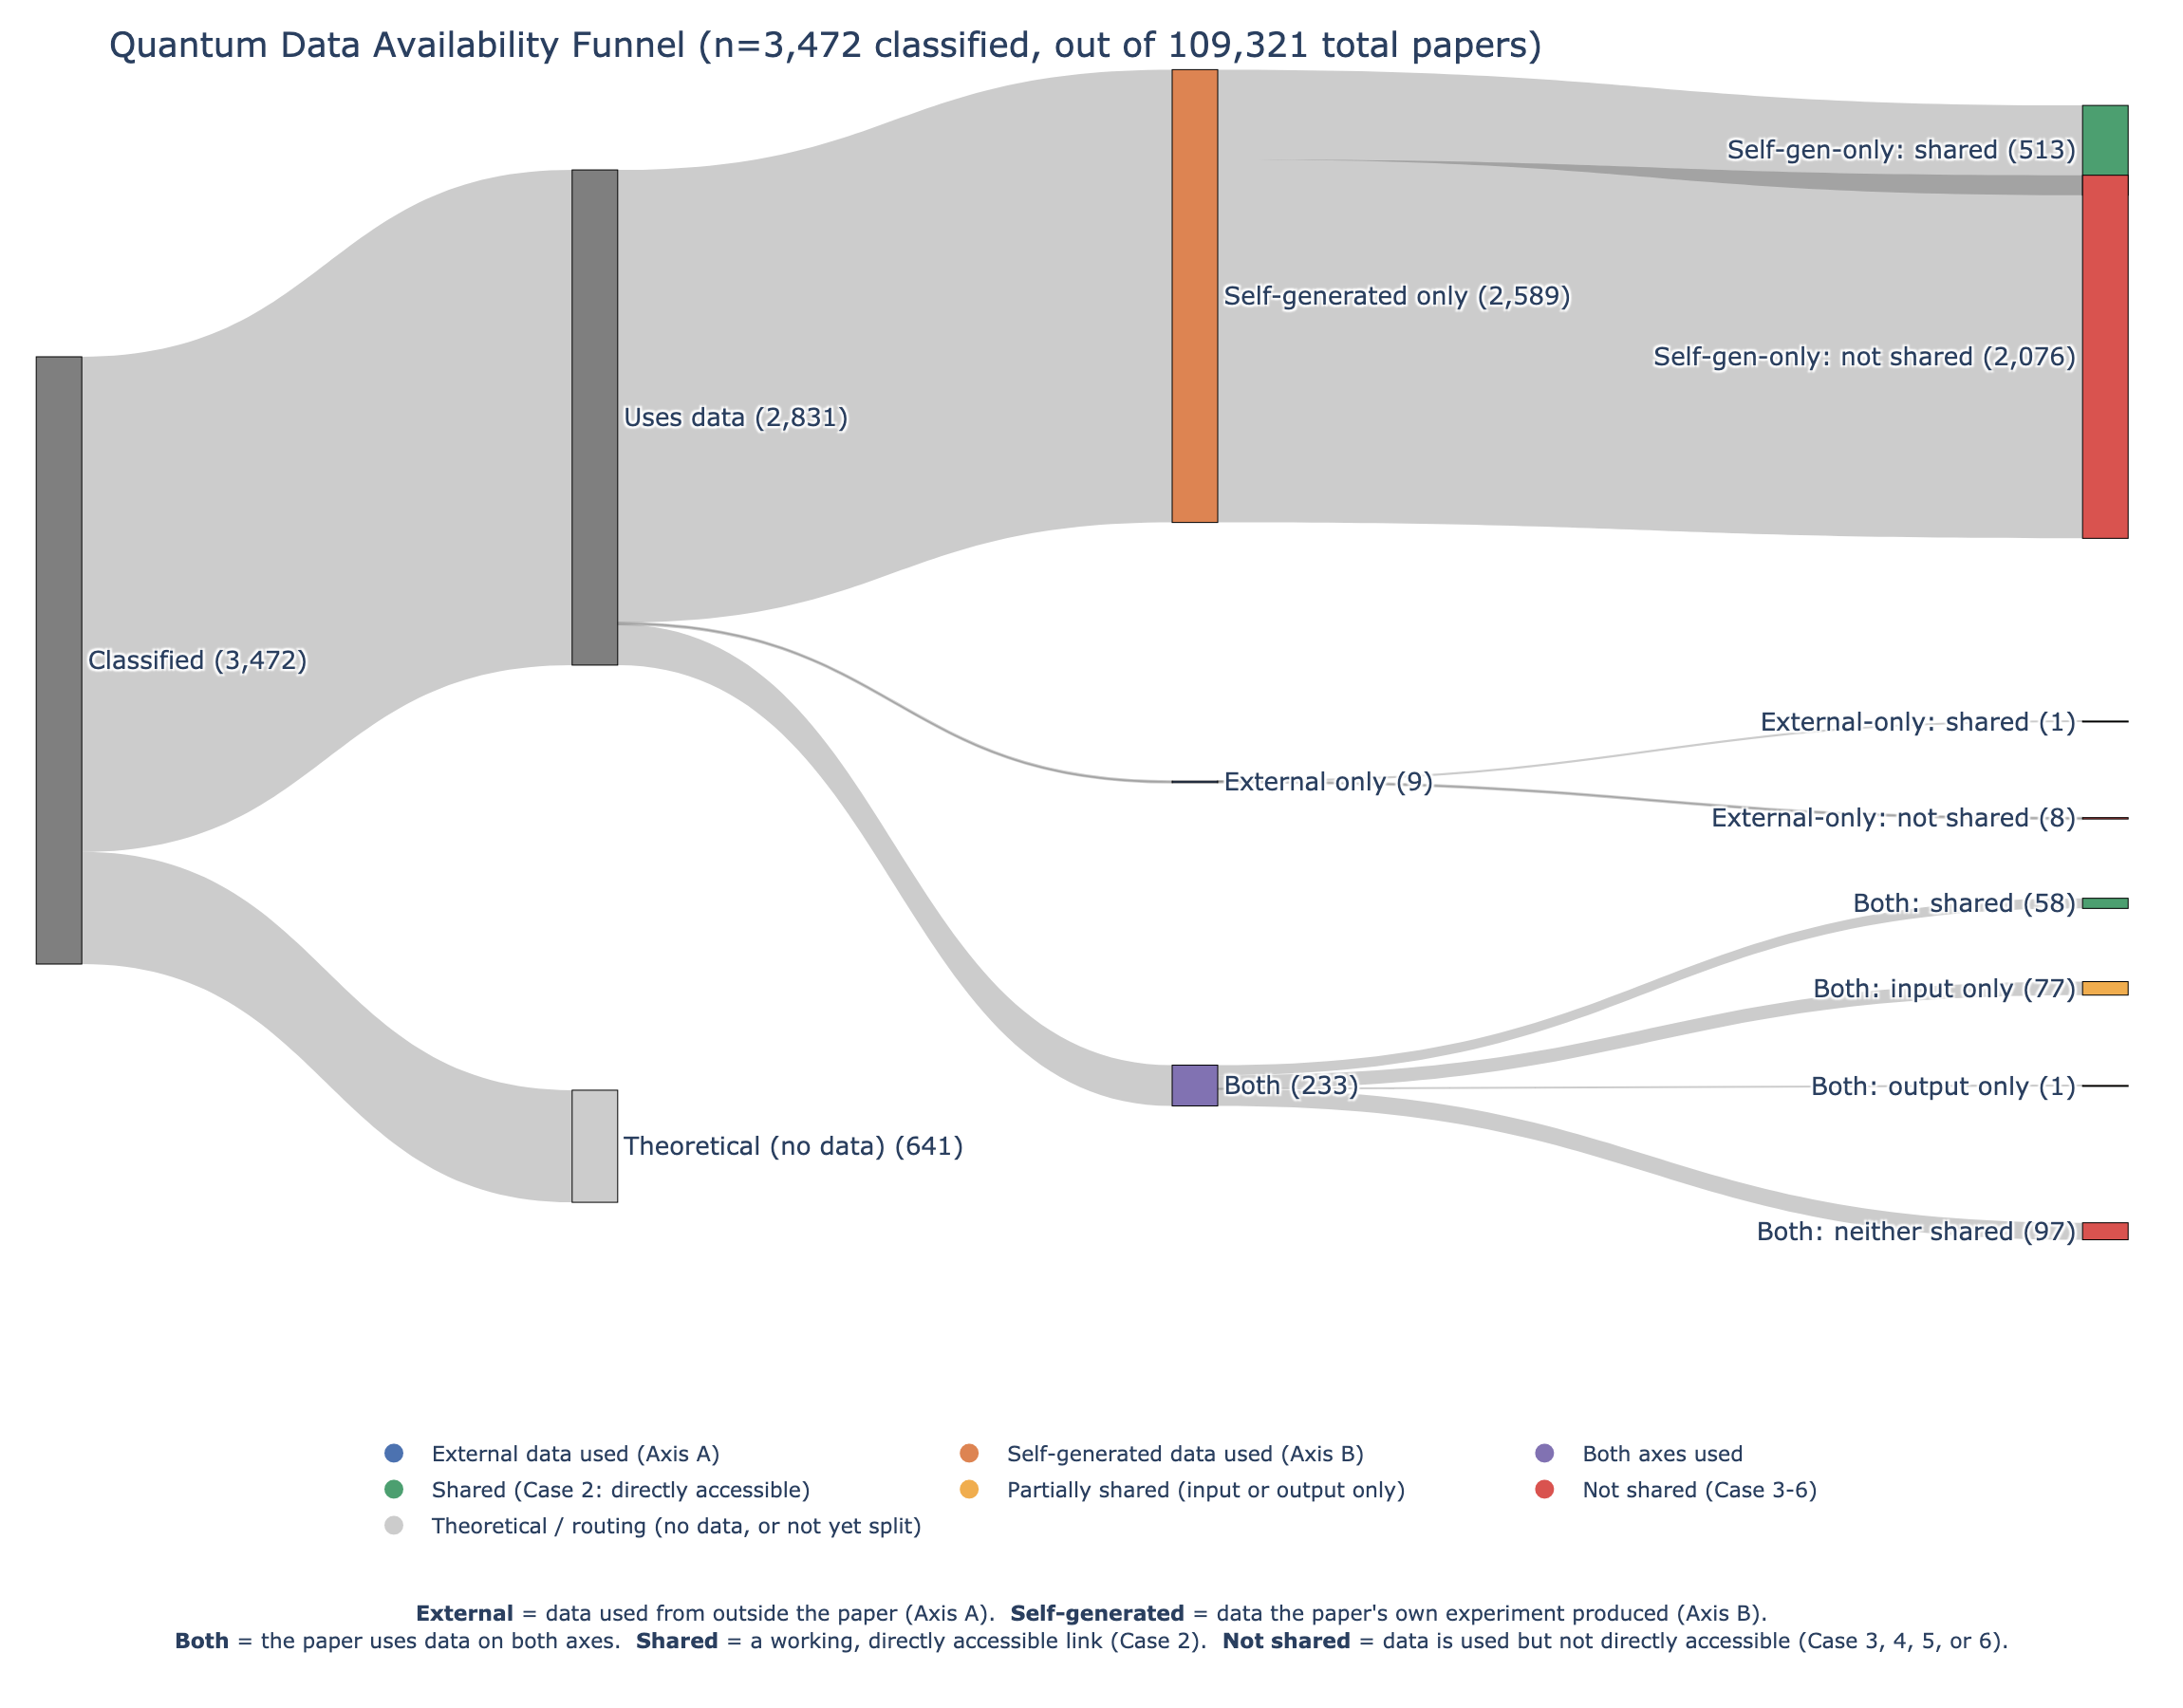

In [14]:
n_quantum = funnel_numbers(quantum_classified)
fig_quantum = make_sankey(n_quantum, "Quantum")
fig_quantum.write_image("funnel_quantum.png", scale=2)
display(Image("funnel_quantum.png"))

## Distribution of reasons data was not shared

Restricted to "not shared" instances (Case 3, 4, 5, or 6 -- the same definition used in
"Shared vs. not shared" above), broken out by *which* of the four reasons applied,
pooled across both axes. A paper with both axes unshared for different reasons
contributes to two reason-buckets, so this counts not-shared *instances*, not papers --
the axis labels below sum to more than the "Not shared" bar count from the earlier
chart for exactly that reason.

- **Named, no access path (Case 3)**: the data is named/cited but no link is given at all.
- **Underspecified (Case 4)**: existence acknowledged but too vague to locate or reconstruct.
- **Claimed accessible, broken link (Case 5)**: a specific link was given and it does not resolve.
- **Available only on request (Case 6)**: no self-service access, only a conditional offer.

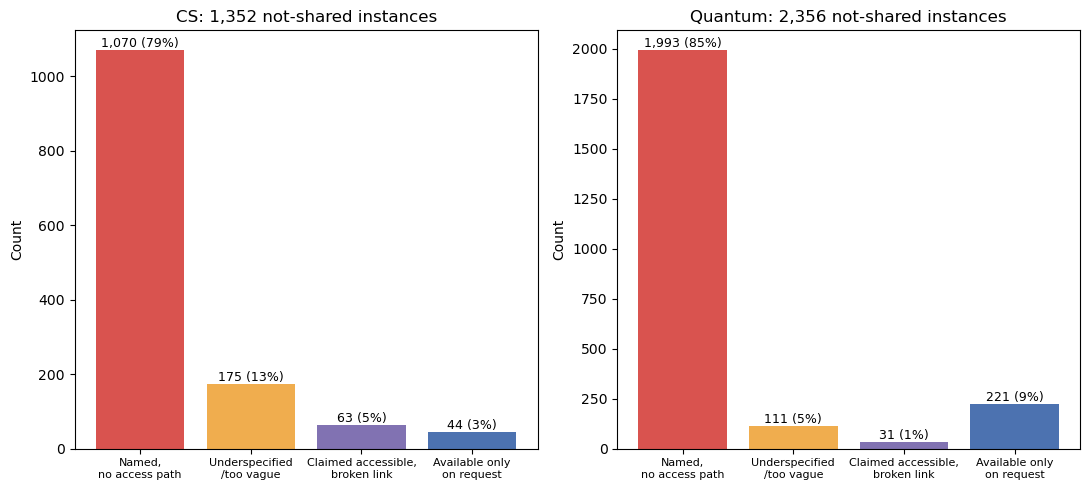

In [15]:
REASON_LABELS = {
    3: "Named,\nno access path",
    4: "Underspecified\n/too vague",
    5: "Claimed accessible,\nbroken link",
    6: "Available only\non request",
}
REASON_COLORS = ["#D9534F", "#F0AD4E", "#8172B2", "#4C72B0"]

def not_shared_reason_counts(df):
    a = case_number(df["Axis A Case"])
    b = case_number(df["Axis B Case"])
    combined = pd.concat([a[a.isin([3, 4, 5, 6])], b[b.isin([3, 4, 5, 6])]])
    return combined.value_counts().reindex([3, 4, 5, 6], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, domain, df in zip(axes, ["CS", "Quantum"], [cs_classified, quantum_classified]):
    counts = not_shared_reason_counts(df)
    total = counts.sum()
    bars = ax.bar([REASON_LABELS[k] for k in counts.index], counts.values, color=REASON_COLORS)
    ax.set_title(f"{domain}: {total:,} not-shared instances")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=8)
    for bar, value in zip(bars, counts.values):
        pct = value / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,} ({pct:.0f}%)",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("not_shared_reasons.png")
plt.show()